Transfer Function H(s):
<TransferFunction>: sys[4]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

                  0.5 s + 2
  ------------------------------------------
  1.5 s^4 + 1.55 s^3 + 6.65 s^2 + 1.35 s + 3


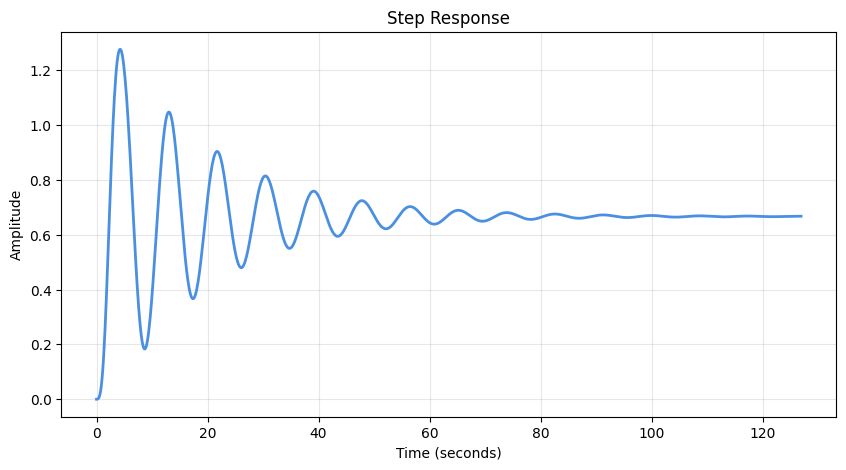

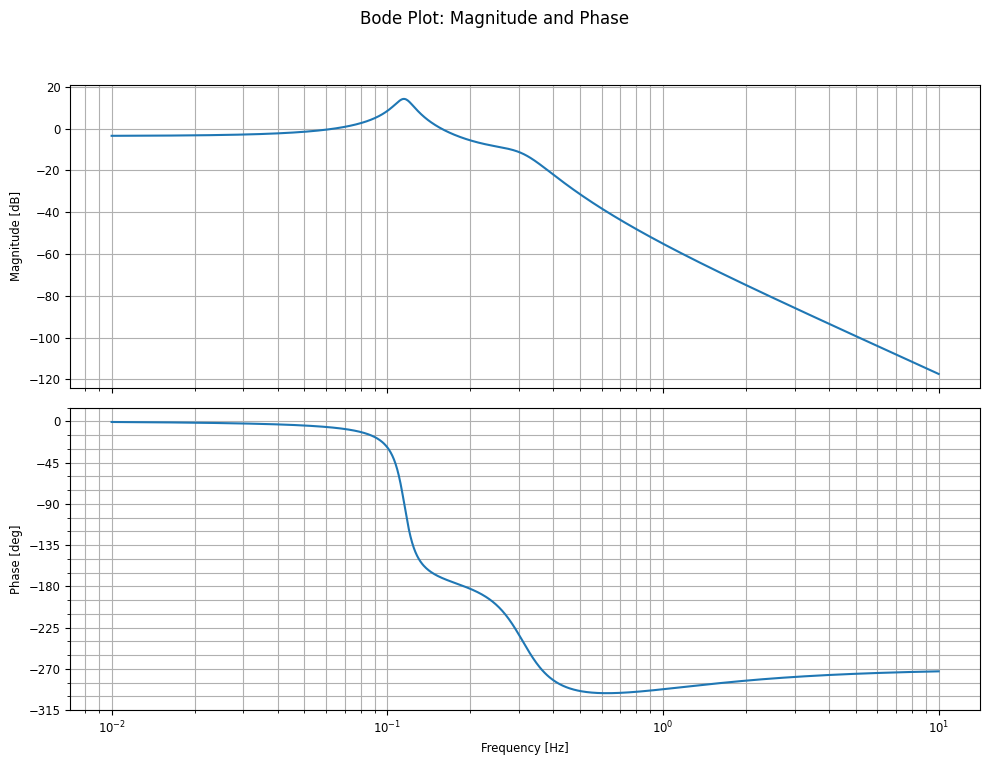

In [2]:
import control
import matplotlib.pyplot as plt
import numpy as np

# Placeholder numerical values for the symbolic parameters
M1 = 1.0  # Mass 1
M2 = 1.5  # Mass 2
B1 = 0.5  # Damping coefficient 1
B2 = 0.3  # Damping coefficient 2
K1 = 2.0  # Spring constant 1
K2 = 1.5  # Spring constant 2

# Definition of the Transfer Function coefficients derived from the expression:
# H(s) = (B1*s + K1) / (M1*M2*s^4 + (B1*M1 + B1*M2 + B2*M1)*s^3 + ...)

# Numerator: B1*s + K1
numerator = [B1, K1]

# Denominator coefficients [s^4, s^3, s^2, s^1, s^0]
denominator = [
    M1 * M2,                                     # s^4
    B1 * M1 + B1 * M2 + B2 * M1,                 # s^3
    B1 * B2 + K1 * M1 + K1 * M2 + K2 * M1,       # s^2
    B1 * K2 + B2 * K1,                           # s^1
    K1 * K2                                      # s^0
]

# Create the control system transfer function object
sys = control.TransferFunction(numerator, denominator)

print("Transfer Function H(s):")
print(sys)

# 1. Step Response Analysis
t, y = control.step_response(sys)

plt.figure(figsize=(10, 5))
plt.plot(t, y, '#4a90e2', linewidth=2)
plt.title('Step Response')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

# 2. Bode Plot Analysis
plt.figure(figsize=(10, 8))
control.bode_plot(sys, dB=True, deg=True, Hz=True)
plt.suptitle('Bode Plot: Magnitude and Phase')

# Rendering results
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()